### Combinatorial Optimization:
>QAP (quadratic assignment problem) test problems of Nugent et al.*
>
>Given n facilities and n locations, each facility needs to be placed to one location. The distance between locations are different. There are flow requirement between each facility. For example, Fifteen facilities are to be placed in 15 locations with five facilities (columns) in three rows of five facilities in each row. The objective is to minimize total flow costs among the placed facilities.
>
>problem complexity 15! = 15 x 14 x ... x 1

### Problem Complexity---NP Hard:
>The QAP is known to be NP-hard, meaning there is no known polynomial-time($n^k$) algorithm to solve it optimally in the general case.
>
>Even for relatively small values of n (e.g., n > 20), exact methods become impractical due to factorial growth in computational requirements.

### Some thoughts
>In this universe we are living, there are about $10^{78}$ to $10^{82}$ atoms. A human body has about $7 * 10^{27}$ atoms on average.
>
>$56! > 10^{82}$
>
>We need some algorithm to find a solution, for example, Genetic Algorithm.
>
>Trade off: Exact solution vs. Computational Time

### Define Objective Function：

>In QAP problem, we are minimizing the flow cost between departments which are placed according to the solution given. My objective funtion for this problem is defined as $ flowCost = \sum\limits _{i = 1} ^{15} \sum\limits _{j = 1} ^{15} distance_{ij} * flow_{ij} $.

>In my setting, I will maintain distance matrix fixed and I will only rearrange flow matrix according to each solution generated eighter by random or by the move operator."

### Global Optimal vs Local Optimal
<div style="text-align: center;">
    <img src="GlobalLocalOpt.png" alt="Alt Text">
</div>

# Genetic Algorithm(GE)
GE is a computer program that uses evolutionary theory to solve problems. It's a type of artificial intelligence (AI) algorithm that mimics natural selection and reproduction.

### Encoding

>Encoding is the representation of solutions in GE algorithm. For this QAP assignment, I will encoding the solution using one dementional Numpy array which holds 15 unique number in range $[0, 15)$. For example, $[ 1, 2, 8, 0, 6, 12, 11,10, 4, 5, 3, 13, 14, 7, 9]$ could be one of my solution representation that indicates department 1 should be placed at location 1, department 2 is placed at location 2 and department 8 is at location 3 etc.

### Initial Population
>In a Genetic Algorithm (GA), the initial population refers to the first set of candidate solutions (individuals) that the algorithm starts with. Key aspects of initial population:
>1. Size: Typically, the population consists of N individuals (solutions), where N is problem-dependent (often between 20 and 500).
>2. Encoding: Each individual is represented as a chromosome (binary string, real-valued vector, or permutation).

### Selection
>Selection is a crucial step in a Genetic Algorithm (GA) where individuals from the current population are chosen to create the next generation.

### Stop Criteria
> when the algorithm should stop.
> 1. preset number of iteration
> 2. if not improved in N generation.

### Crossover
>Crossover is a key genetic operator in Genetic Algorithms (GA) used to combine genetic information from two parent solutions to produce new offspring. This mimics biological reproduction and helps explore the solution space.

### Mutation
> Mutation is another key genetic operator in Genetic Algorithms (GA) used to introduce randomness into the population. It mimics the natural mutation process, ensuring that small changes are made to the genetic material of individuals, which helps maintain diversity in the population and prevents the algorithm from prematurely converging to a local optimum.

### Genetic Algorithm Flowchart
<div style="text-align: center;">
    <img src="GeFlow.png" alt="Alt Text">
</div>

In [1]:
#import libraries
import numpy as np
import random
import matplotlib.pyplot as plt

In [10]:
# Quadratic Assignment Problem dataset n = 15
# flow and distance
# Flow matrix means the flwo between departments. 
# Distance matrix means the distance betw
# In this assignment, I will maintain distance matrix unchanged
# Whenever I have a new solution, I will call function to rearrange flow matrix.

flow = np.array([[0, 10, 0, 5, 1, 0, 1, 2, 2, 2, 2, 0, 4, 0, 0],
                [10, 0, 1, 3, 2, 2, 2, 3, 2, 0, 2, 0, 10, 5, 0],
                [0, 1, 0, 10, 2, 0, 2, 5, 4, 5, 2, 2, 5, 5, 5],
                [5, 3, 10, 0, 1, 1, 5, 0, 0, 2, 1, 0, 2, 5, 0],
                [1, 2, 2, 1, 0, 3, 5, 5, 5, 1, 0, 3, 0, 5, 5],
                [0, 2, 0, 1, 3, 0, 2, 2, 1, 5, 0, 0, 2, 5, 10],
                [1, 2, 2, 5, 5, 2, 0, 6, 0, 1, 5, 5, 5, 1, 0],
                [2, 3, 5, 0, 5, 2, 6, 0, 5, 2, 10, 0, 5, 0, 0],
                [2, 2, 4, 0, 5, 1, 0, 5, 0, 0, 10, 5, 10, 0, 2],
                [2, 0, 5, 2, 1, 5, 1, 2, 0, 0, 0, 4, 0, 0, 5],
                [2, 2, 2, 1, 0, 0, 5, 10, 10, 0, 0, 5, 0, 5, 0],
                [0, 0, 2, 0, 3, 0, 5, 0, 5, 4, 5, 0, 3, 3, 0],
                [4, 10, 5, 2, 0, 2, 5, 5, 10, 0, 0, 3, 0, 10, 2],
                [0, 5, 5, 5, 5, 5, 1, 0, 0, 0, 5, 3, 10, 0, 4],
                [0, 0, 5, 0, 5, 10, 0, 0, 2, 5, 0, 0, 2, 4, 0]])

dist = np.array([[0, 1, 2, 3, 4, 1, 2, 3, 4, 5, 2, 3, 4, 5, 6],
                [1, 0, 1, 2, 3, 2, 1, 2, 3, 4, 3, 2, 3, 4, 5],
                [2, 1, 0, 1, 2, 3, 2, 1, 2, 3, 4, 3, 2, 3, 4],
                [3, 2, 1, 0, 1, 4, 3, 2, 1, 2, 5, 4, 3, 2, 3],
                [4, 3, 2, 1, 0, 5, 4, 3, 2, 1, 6, 5, 4, 3, 2],
                [1, 2, 3, 4, 5, 0, 1, 2, 3, 4, 1, 2, 3, 4, 5],
                [2, 1, 2, 3, 4, 1, 0, 1, 2, 3, 2, 1, 2, 3, 4],
                [3, 2, 1, 2, 3, 2, 1, 0, 1, 2, 3, 2, 1, 2, 3],
                [4, 3, 2, 1, 2, 3, 2, 1, 0, 1, 4, 3, 2, 1, 2],
                [5, 4, 3, 2, 1, 4, 3, 2, 1, 0, 5, 4, 3, 2, 1],
                [2, 3, 4, 5, 6, 1, 2, 3, 4, 5, 0, 1, 2, 3, 4],
                [3, 2, 3, 4, 5, 2, 1, 2, 3, 4, 1, 0, 1, 2, 3],
                [4, 3, 2, 3, 4, 3, 2, 1, 2, 3, 2, 1, 0, 1 ,2],
                [5, 4, 3, 2, 3, 4, 3, 2, 1, 2, 3, 2, 1, 0, 1],
                [6, 5, 4, 3, 2, 5, 4, 3, 2, 1, 4, 3, 2, 1, 0]])

# ### simplified problem
# flow = np.array([[0, 10, 0, 5, 1],
#                 [10, 0, 1, 3, 2],
#                 [0, 1, 0, 10, 2],
#                 [5, 3, 10, 0, 1],
#                 [1, 2, 2, 1, 0]])


# dist = np.array([[0, 1, 2, 3, 4],
#                 [1, 0, 1, 2, 3],
#                 [2, 1, 0, 1, 2],
#                 [3, 2, 1, 0, 1],
#                 [4, 3, 2, 1, 0]])

In [3]:
# Total cost is defined as sum of pairwise multiplication on flow and distance

def cost(flow):
    """
    Calculate total cost for one solution

    Args:
        flow(2x2 matrix): a flow matrix 2 x 2

    Return:
        total: the total cost by sum all the flow x distance.
    """
    total = 0
    for f, d in zip(flow, dist):
        total = total + np.dot(f, d)
    return total


def flow_transform(solution):
    """
    Flow matrix tramsformation based on the solution

    Args:
        solution: a 1 dimensional list or numpy array

    Return:
        flow: a new flow matrix according to the solution.
    """
    flow_transformed = np.zeros((solution.shape[0], solution.shape[0]))
    for i in range(solution.shape[0]):
        for j in range(solution.shape[0]):
            flow_transformed[i][j] = flow[int(solution[i])][int(solution[j])]
            flow_transformed[j][i] = flow[int(solution[j])][int(solution[i])]
        # print(i)
        # print(flow_transformed)
    return flow_transformed

def popu_fitness(solu_population):
    """
    Calculate fitness of a population

    Args:
        solu_population: a set of solutions as the population in GE

    Return:
        fitness: a one dimensional array contains the fitness of all indivisuals in the population
    """
    length = solu_population.shape[0]
    fitness = np.zeros(length)
    for i in range(length):
        flow_transformed = flow_transform(solu_population[i])
        fitness[i] = cost(flow_transformed)
    return fitness

### Encoding & Move Operators

In [4]:
### Random key encoding and decoding

def randkey_encode():
    solu = np.array(random.sample(range(0, 100), flow.shape[0]))
    return solu/100

def randkey_decode(randkey):
    return np.argsort(randkey)

key = randkey_encode()
solu = randkey_decode(key)
print(key)
print(solu)

[0.76 0.37 0.56 0.13 0.35]
[3 4 1 2 0]


### Uniform Crossover & Mutation

In [5]:
def crossover(one, two):
    child = np.zeros(flow.shape[0])
    for i in range(flow.shape[0]):
        threshold = random.uniform(0, 1)
        if threshold >= 0.5:
            child[i] = one[i]
        else:
            child[i] = two[i]
    return child

def mutation(curr_solu, prob):
    """
    Perform the mutation for a child after crossover

    Args:
        curr_solu: the child 
        prob: a small value to determine when to perform the mutation

    Return:
        child: a child after mutation or skip the mutation
    """
    for i in range(curr_solu.shape[0]):
        threshold = random.uniform(0, 1)
        if threshold < prob:
            curr_solu[i] = random.uniform(0, 1)
    return curr_solu

### Initial Population

In [6]:
def init_popu(size):
    """
    Initial population generator

    Args:
        size: an integer to specify the size of initial population

    Return:
        popu: a set of solution as the nitial population
    """
    popu = np.zeros((size, flow.shape[0]))
    for i in range(size):
        solu_key = randkey_encode()
        popu[i] = solu_key
    return popu

def decode_popu(popu):
    """
    Decode the population

    Args:
        popu: a set of solutions as a population

    Return:
        decoded_popu: a set of decoded solutions as a population
    """
    decoded_popu = np.zeros((popu.shape[0], popu.shape[1]))
    for i in range(popu.shape[0]):
        decoded_popu[i] = randkey_decode(popu[i])
    return decoded_popu

In [7]:
def ga(init_popu_size, prob_mutation, max_iter):
    """
    Main GA function

    Args:
        init_popu_size: initial popuation size
        prob_mutation: a small value to determine when to perform the mutation
        max_iter: Algorithm stop criteria

    Return:
        decoded_popu: a set of decoded solutions as a population
    """
    init_solu_popu = init_popu(init_popu_size)
    best_fit_list = [] ### place holder to store the best fit solution
    for i in range(max_iter):
        decoded_solu = decode_popu(init_solu_popu)
        fit = popu_fitness(decoded_solu)### calculating the fitness for parent selection
        argIndex = np.argsort(fit)

        ### random select 2 parents from the better half
        ### this might avoid superparent in every generation. 
        for i in range(int(init_popu_size/2)):
            # choose the parents
            rand_top_half = random.sample(range(0, int(init_popu_size / 2)), 2)
            first_parent = init_solu_popu[argIndex[rand_top_half[0]]]
            second_parent = init_solu_popu[argIndex[rand_top_half[1]]]

            ### crossover
            first_child = crossover(first_parent, second_parent)
            second_child = crossover(first_parent, second_parent)

            ### mutation
            first_child = mutation(first_child, prob_mutation)
            second_child = mutation(second_child, prob_mutation)

            ### selection
            child_add_popu = np.concatenate((init_solu_popu, [first_child, second_child]))
            child_add_decoded = decode_popu(child_add_popu)
            child_added_fit = popu_fitness(child_add_decoded)
            child_add_argIndex = np.argsort(child_added_fit)
            
            init_solu_popu = child_add_popu[child_add_argIndex[0: init_popu_size]]
        best_fit_list.append(child_added_fit[child_add_argIndex[0]])
    decoded_solu = decode_popu(init_solu_popu)
    fit = popu_fitness(decoded_solu)
    best_solution = randkey_decode(init_solu_popu[np.argsort(fit)[0]])
    return np.amin, best_solution, best_fit_list

In [11]:
best_fit, best_solution, best_fit_hist = ga(100, 0.02, 200)

In [12]:
best_fit_hist

[1400.0,
 1400.0,
 1360.0,
 1360.0,
 1360.0,
 1360.0,
 1316.0,
 1316.0,
 1316.0,
 1316.0,
 1316.0,
 1314.0,
 1314.0,
 1314.0,
 1302.0,
 1302.0,
 1302.0,
 1302.0,
 1258.0,
 1258.0,
 1258.0,
 1258.0,
 1258.0,
 1258.0,
 1258.0,
 1258.0,
 1258.0,
 1258.0,
 1258.0,
 1258.0,
 1258.0,
 1258.0,
 1254.0,
 1254.0,
 1254.0,
 1254.0,
 1254.0,
 1254.0,
 1254.0,
 1254.0,
 1254.0,
 1254.0,
 1254.0,
 1254.0,
 1254.0,
 1254.0,
 1254.0,
 1254.0,
 1254.0,
 1254.0,
 1254.0,
 1254.0,
 1254.0,
 1254.0,
 1254.0,
 1254.0,
 1254.0,
 1254.0,
 1254.0,
 1254.0,
 1254.0,
 1254.0,
 1254.0,
 1254.0,
 1254.0,
 1254.0,
 1254.0,
 1254.0,
 1254.0,
 1254.0,
 1254.0,
 1254.0,
 1254.0,
 1254.0,
 1254.0,
 1254.0,
 1254.0,
 1254.0,
 1254.0,
 1254.0,
 1254.0,
 1254.0,
 1254.0,
 1254.0,
 1254.0,
 1214.0,
 1214.0,
 1214.0,
 1214.0,
 1214.0,
 1214.0,
 1214.0,
 1214.0,
 1214.0,
 1214.0,
 1214.0,
 1214.0,
 1214.0,
 1214.0,
 1214.0,
 1214.0,
 1214.0,
 1214.0,
 1214.0,
 1214.0,
 1214.0,
 1214.0,
 1214.0,
 1214.0,
 1214.0,
 1214.0,
 

Text(0, 0.5, 'Value')

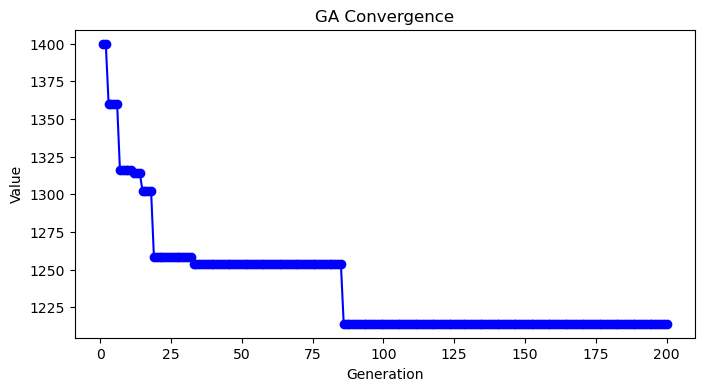

In [13]:
plt.figure(figsize=(8, 4))
plt.plot(list(range(1, len(best_fit_hist) + 1)), best_fit_hist, marker='o', linestyle='-', color='b')

# Add labels and title
plt.title('GA Convergence')
plt.xlabel('Generation')
plt.ylabel('Value')